In [101]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(ggplot2)
library(microshades)
library(openxlsx)
library(GenomicSEM)
library(semptools)

In [102]:
sample_sizes <- read_csv(
  "
Pheno,Nca,Nco,Neff
Clin_MDD,26778,51857,62534.02
EHR,311831,1180439,858540.6
Quest,70887,339597,222675.7
Help,113769,208811,294577.7
Clin_BIP,27196,43792,67108.0876767904
Comm,32091,737230,123009.500221624
BDI,25060,449978,94951.971673845
BDII,6781,364075,26628.0451172423
ADHD,19099,34194,45684.86
AN,16992,55525,46321.9
ALC,NA,NA,26853.43
ASD,18381,27969,44366.62
MDD,357636,1281936,1118502.79
BMI,NA,NA,681275
CAD,95830,385536,285937.77
Chrono,NA,NA,449734
CRP,NA,NA,204402
Height,NA,NA,693529
Neu,NA,NA,390278
PD,2147,7760,6665.06
PTSD,23212,151447,140475
SCZ,53386,77258,117498.3
Smoking,NA,NA,263954
T2D,80154,853816,251739.50
PartEM,NA,NA,356560.32
PartMH,NA,NA,311999.52
PartSF,NA,NA,449041.88
"
)

#BIP,59287,781022,163367

Rows: 27 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Pheno
dbl (3): Nca, Nco, Neff

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Population and sample prevalences

In [103]:
#sample prevalences can be set to 0.5 as N for the munged files has been converted to effective N. It could also be odne by specifying the correct sample prevalence when convertint to the liability scale, but for compatibility purposes the neffe variant has been applied
bip_prevalences <- c("Clin_BIP" = 0.02, "Comm" = 0.02, "BDI" = 0.01, "BDII" = 0.01)
mdd_prevalences <- c("Clin_MDD" = 0.15, "EHR" = 0.15, "Quest" = 0.15, "Help" = 0.3)

bip_names <- names(bip_prevalences)
mdd_names <- names(mdd_prevalences)

core_names <- c(mdd_names, bip_names)

other_prevalences <- c(
  "ADHD" = 0.03, "ALC" = 0.16, "AN" = 0.01,
  "ASD" = 0.01, "MDD" = 0.15, "BMI" = NA,
  "CAD" = 0.05, "Chrono" = NA, "CRP" = NA,
  "Height" = NA, "Neu" = NA, "PD" = 0.03,
  "PTSD" = 0.3, "SCZ" = 0.01, "Smoking" = NA,
  "T2D" = 0.06, "PartEM" = 0.6, "PartMH" = 0.3, "PartSF" = 0.5
)
other_names <- names(other_prevalences)

all_prevalences <- c(mdd_prevalences, bip_prevalences, other_prevalences)
all_names <- names(all_prevalences)

#"BIP" = 0.01

## LDSC

In [104]:
#load the paths of necessary documents as not all of them are in this directory
ld <- "/local1/hdata/REF/eur_ref_ld_chr"
weights <- "/local1/hdata/REF/eur_w_ld_chr"
samples <- c("/local1/hdata/sumstats/munged/Clin.sumstats.gz",
             "/local1/hdata/sumstats/munged/EHR.sumstats.gz",
             "/local1/hdata/sumstats/munged/Quest.sumstats.gz",
             "/local1/hdata/sumstats/munged/Help.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_clinical_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_community_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDI_cleaned_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDII_cleaned_neff.sumstats.gz")
other_basepath <- "/local1/scratch/pazweifel/sumstats_ambits/munged/" #phenotype.sumstats.gz

In [105]:
#create a matrices directory
dir.create("matrices_mdd_bip", showWarnings = FALSE)
#create a path for a covstruct object where you store the covariance structure of the bipolar disorders and store it in the matrices directory
covstruct_core <- here::here("matrices_mdd_bip",paste("MDD_BD", "R", sep = "."))
#extract population prevalence 
pop_prev <- as.vector(all_prevalences[core_names])
#fill the samp_prev vector depending on the pop_prev vector, if NA use NA and if not use 0.5
samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
if (!file.exists(covstruct_core)){
    covstruct_core_ldsc <- ldsc(
        traits = samples,
        trait.names = core_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_core_ldsc, covstruct_core, control = c("all", "digits17"))
}

In [106]:
# do the same thing but include the other phenotypes one by one and name them after the current phenotype used
for (phenotype in other_names){
    covstruct_pheno <- here::here("matrices_mdd_bip",paste(phenotype,"R", sep = "."))
    #extract population prevalences
    pop_prev <- c(all_prevalences[core_names], all_prevalences[phenotype])
    #fill the sample prevalences depending on pop vector
    samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
    #concatenate the sample vector with the bip filepaths and the specific single phenotype filepath
    if (phenotype == "MDD"){
        samples_plus1 <- c(samples, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
    }
    else {
        samples_plus1 <- c(samples, paste0(other_basepath,phenotype,".sumstats.gz"))
    }
    #check if file already exists
    if (!file.exists(covstruct_pheno)){
        covstruct_ldsc <- ldsc(
            traits = samples_plus1,
            trait.names = c(core_names, phenotype),
            sample.prev = samp_prev,
            population.prev = pop_prev,
            ld = ld,
            wld = weights,
            stand = TRUE
        )
        dput(covstruct_ldsc, covstruct_pheno, control = c("all", "digits17"))
    }
}
        

## Modelling

In [107]:
#First define the base model
#get the base covariance matrix from the matrices directory
covstruct_core <- dget(here::here("matrices_mdd_bip/MDD_BD.R"))
#define the model using NA*Clin to say that this parameter loading has to be freely estimated, we fix the factor variance to 1 and ensure residual genetic variance of phenotypes isnt negative
base_model <- "BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
MD ~~ 1*MD
BD~~1*BD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001"

base.fit <- usermodel(covstruct_core,
                      estimation = "DWLS",
                      model = base_model,
                      imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.339 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00273284163554166 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.256201817609998 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct_core, estimation = "DWLS", model = base_model, :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [108]:
base.fit$modelfit

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,626.4503,19,1.312547e-120,660.4503,0.9364174,0.09950236


In [109]:
dim(covstruct_core$V_Stand)[1]

[1] 36

Clin_MDD,EHR,Quest,Help,Clin_BIP,Comm,BDI,BDII
0.11371854,0.05510735,0.06217788,0.06164107,0.06302062,0.07116500,0.05499316,0.09285287
0.05510735,0.04021429,0.03959542,0.03848468,0.03880800,0.04078511,0.03355534,0.05698347
0.06217788,0.03959542,0.05427513,0.04623651,0.04266039,0.05229140,0.03782342,0.06957016
0.06164107,0.03848468,0.04623651,0.04814393,0.04029261,0.04988629,0.03660986,0.06762559
0.06302062,0.03880800,0.04266039,0.04029261,0.05691824,0.05697720,0.05415812,0.07875669
0.07116500,0.04078511,0.05229140,0.04988629,0.05697720,0.07845389,0.05672839,0.08664490
0.05499316,0.03355534,0.03782342,0.03660986,0.05415812,0.05672839,0.05427365,0.07053401
0.09285287,0.05698347,0.06957016,0.06762559,0.07875669,0.08664490,0.07053401,0.15183248


x,y,values,se
<fct>,<fct>,<dbl>,<dbl>
Clin_MDD,Clin_MDD,1.00,0.11
EHR,Clin_MDD,0.84,0.06
Quest,Clin_MDD,0.80,0.06
Help,Clin_MDD,0.85,0.06
Clin_BIP,Clin_MDD,0.43,0.06
Comm,Clin_MDD,0.69,0.07
BDI,Clin_MDD,0.36,0.05
BDII,Clin_MDD,0.78,0.09
Clin_MDD,EHR,0.84,0.06


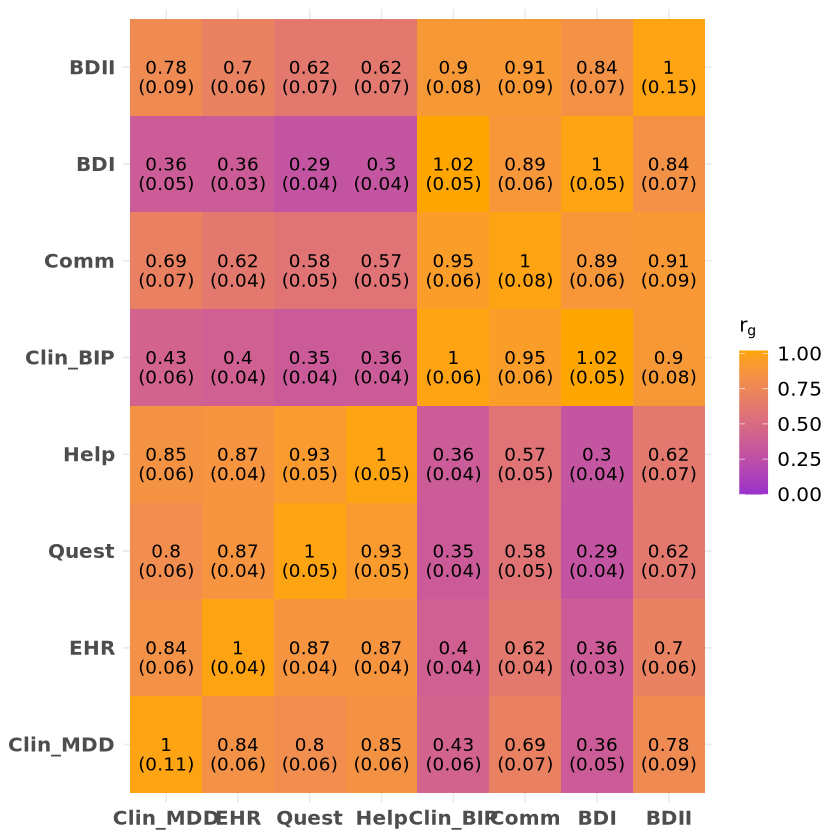

In [110]:
sstand <- covstruct_core$S_Stand
vstand <- covstruct_core$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:dim(vstand)[1]), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
expanded_df
#create the ggplot
correlation_plot <- ggplot(expanded_df, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(0, max(expanded_df$values))) +
theme_minimal() +
geom_tile() +
theme(axis.text = element_text(face = "bold", size = 12), axis.title = element_blank(), legend.text = element_text(size = 12), legend.title = element_text(size = 12)) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

In [111]:
ggsave("/local1/home/pazweifel/plots/bip_paper/mdd_bip/bip_mdd_correlation_matrix.pdf", width = 10, height = 8, device = "pdf")

In [112]:
#same thing but with fixed loading of 1 on the clinical, factor variance freely estimated
anchor_model <- "BD=~1*Clin_BIP+Comm+BDI+BDII
MD =~ 1*Clin_MDD + EHR + Quest + Help
MD ~~ BD
MD ~~ MD
BD~~BD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001"
anchor.fit <- usermodel(covstruct_core,
                        estimation = "DWLS",
                        model = anchor_model,
                        imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.381 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00273284163554166 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.256201817609998 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct_core, estimation = "DWLS", model = anchor_model, :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [113]:
anchor.fit$results

,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
4,BD,=~,Comm,0.645707123,0.0337938885586274,1.18421411,0.0619739537708771,1.18421411,2.19891916357014e-81
1,BD,=~,BDI,0.748524070,0.0191606124430581,0.90429109,0.0231465566076654,0.80495981,< 5e-300
2,BD,=~,BDII,0.796554867,0.0392779526940584,1.20117636,0.0592217745200424,1.20117636,1.93332696515457e-91
15,MD,=~,EHR,0.758898721,0.0389660573595236,1.02461090,0.0526086639145953,0.95119484,1.75835264756135e-84
17,MD,=~,Quest,0.879670650,0.0477389532165681,0.98322614,0.0533581534563431,0.91277574,8.02525210962982e-76
16,MD,=~,Help,0.972294828,0.0500026433375289,0.99757296,0.0513022683491638,0.92609428,3.22098990787365e-84
6,BD,~~,MD,0.059423855,0.00564498948923378,0.43486539,0.0413122721846912,0.52623345,6.49849168450712e-26
18,MD,~~,MD,0.084591069,0.00822104207014221,0.86182881,0.0837570866490908,0.86182881,7.85181836200625e-25
5,BD,~~,BD,0.150729760,0.0108094061849883,0.79237685,0.0568290261238791,0.79237685,3.40705403667905e-44


## Pathway models


In [114]:
#define the common and the independent pathway models and introduce a placeholder which can filled by the repsective phenotype corresponding to the used covariance matrix
#set the factor variance to 1
common.model <- "BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
BD~~{trait}
MD~~{trait}
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001
"

independent.model <- "BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~{trait}
Comm~~{trait}
BDI~~{trait}
BDII~~{trait}
Clin_MDD~~{trait}
EHR~~{trait}
Quest~~{trait}
Help~~{trait}
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001
"

In [115]:
#define a list with trait names named after themselves, so that that the naming remains when using this list with lapply and therefore specific elements can be accessed by name
traits <- other_names
names(traits) <- traits
traits

ADHD       ALC        AN       ASD       MDD       BMI       CAD    Chrono 
   "ADHD"     "ALC"      "AN"     "ASD"     "MDD"     "BMI"     "CAD"  "Chrono" 
      CRP    Height       Neu        PD      PTSD       SCZ   Smoking       T2D 
    "CRP"  "Height"     "Neu"      "PD"    "PTSD"     "SCZ" "Smoking"     "T2D" 
   PartEM    PartMH    PartSF 
 "PartEM"  "PartMH"  "PartSF"

In [116]:
#make a named vector with all the common models and all the applied models, take advantage of the palceholder introduced
traits_common.models <- lapply(traits, 
                               function(trait) str_glue(common.model)
)

traits_independent.models <- lapply(traits,
                                    function(trait) str_glue(independent.model)
)

In [117]:
traits_independent.models

$ADHD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~ADHD
Comm~~ADHD
BDI~~ADHD
BDII~~ADHD
Clin_MDD~~ADHD
EHR~~ADHD
Quest~~ADHD
Help~~ADHD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$ALC
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~ALC
Comm~~ALC
BDI~~ALC
BDII~~ALC
Clin_MDD~~ALC
EHR~~ALC
Quest~~ALC
Help~~ALC
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$AN
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~AN
Comm~~AN
BDI~~AN
BDII~~AN
Clin_MDD~~AN
EHR~~AN
Quest~~AN
Help~~AN
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$ASD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~ASD
Comm~~ASD
BDI~~ASD
BDII~~ASD
Clin_MDD~~ASD
EHR~~ASD
Quest~~ASD
Help~~ASD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$MDD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~MDD
Comm~~MDD
BDI~~MDD
BDII~~MDD
Clin_MDD~~MDD
EHR~~MDD
Quest~~MDD
Help~~MDD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$BMI
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~BMI
Comm~~BMI
BDI~~BMI
BDII~~BMI
Clin_MDD~~BMI
EHR~~BMI
Quest~~BMI
Help~~BMI
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$CAD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~CAD
Comm~~CAD
BDI~~CAD
BDII~~CAD
Clin_MDD~~CAD
EHR~~CAD
Quest~~CAD
Help~~CAD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$Chrono
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~Chrono
Comm~~Chrono
BDI~~Chrono
BDII~~Chrono
Clin_MDD~~Chrono
EHR~~Chrono
Quest~~Chrono
Help~~Chrono
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$CRP
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~CRP
Comm~~CRP
BDI~~CRP
BDII~~CRP
Clin_MDD~~CRP
EHR~~CRP
Quest~~CRP
Help~~CRP
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$Height
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~Height
Comm~~Height
BDI~~Height
BDII~~Height
Clin_MDD~~Height
EHR~~Height
Quest~~Height
Help~~Height
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$Neu
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~Neu
Comm~~Neu
BDI~~Neu
BDII~~Neu
Clin_MDD~~Neu
EHR~~Neu
Quest~~Neu
Help~~Neu
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$PD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~PD
Comm~~PD
BDI~~PD
BDII~~PD
Clin_MDD~~PD
EHR~~PD
Quest~~PD
Help~~PD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$PTSD
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~PTSD
Comm~~PTSD
BDI~~PTSD
BDII~~PTSD
Clin_MDD~~PTSD
EHR~~PTSD
Quest~~PTSD
Help~~PTSD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$SCZ
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~SCZ
Comm~~SCZ
BDI~~SCZ
BDII~~SCZ
Clin_MDD~~SCZ
EHR~~SCZ
Quest~~SCZ
Help~~SCZ
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

$Smoking
BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
Clin_BIP~~Smoking
Comm~~Smoking
BDI~~

In [118]:
#load the genetic covariance matrices
trait.covstructs <- lapply(traits, 
                           function(trait) dget(here::here("matrices_mdd_bip",paste(trait,"R", sep = ".")))
)

In [119]:
traits_common.models[["ADHD"]]

BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
BD~~ADHD
MD~~ADHD
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001

In [120]:
#now fit the common and the independent models using the two vectors
trait_common.fit <- lapply(traits, 
                           function(trait) {
                               usermodel(trait.covstructs[[trait]],
                               estimation = "DWLS",
                               model = traits_common.models[[trait]],
                               imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.368 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027464933579921 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259227033626853 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.419 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027326202628988 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.258431518857108 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.734 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00275283214683422 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.252289966167645 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.343 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00270921997770598 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259223948618253 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.392 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00275780853289925 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.46925602258717 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [121]:
trait_independent.fit <- lapply(traits,
                                function(trait) {
                                    usermodel(
                                        trait.covstructs[[trait]],
                                        estimation = "DWLS",
                                        model = traits_independent.models[[trait]],
                                        imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.33 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027464933579921 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259227033626853 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.368 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027326202628988 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.258431518857108 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.346 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00275283214683422 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.252289966167645 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.377 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00270921997770598 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259223948618253 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.439 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00275780853289925 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.46925602258717 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[

## ChiSquared difference between common and independent model

In [122]:
#define the chisquared function: a smaller chi squared value means that the estimated models covariance structure fits the observed covariance structure well
#if you subtract the chi squared of the independent model from the common one, you can see how much better it is
#the difference follows a chisquared distribution and you can calculate the p value of this observation

model_diff_chisq <- function(common_model, independent_model) {
    q_chisq <- common_model$modelfit$chisq - independent_model$modelfit$chisq
    q_df <- common_model$modelfit$df - independent_model$modelfit$df
    q_p <- pchisq(q = q_chisq, df = q_df, lower.tail =FALSE)
    data.frame(q_chisq, q_df, q_p)
}

model_diffs <- bind_rows(
    lapply(traits, function(trait) {
        model_diff_chisq(trait_common.fit[[trait]], trait_independent.fit[[trait]])
        }
    ),
    .id = "Trait"
    ) %>% 
    mutate(FDR = p.adjust(q_p, method = "fdr"))

In [123]:
#merge with samplesize df first
model_diff_neff_df <- left_join(model_diffs, sample_sizes, by = c("Trait" = "Pheno"))
model_diff_neff_df$Significant <- ifelse(model_diff_neff_df$FDR < 0.05, "FDR < 0.05", "No")

In [124]:
require(ggrepel)
model_diff_neff_df %>% subset(select = c(Trait, q_chisq, q_df, q_p, FDR)) %>% mutate(FDR_stars = case_when(
    FDR < 0.001 ~ "***",
    FDR < 0.01 ~ "**",
    FDR < 0.05 ~ "*",
    TRUE ~ "")) 

,Trait,q_chisq,q_df,q_p,FDR,FDR_stars
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ADHD,35.124809,6,4.076072e-06,8.605040e-06,***
2,ALC,-1.098902,6,1.000000e+00,1.000000e+00,
3,AN,27.858709,6,9.989743e-05,1.898051e-04,***
4,ASD,48.176996,6,1.089199e-08,4.138955e-08,***
5,MDD,-1232.163777,6,1.000000e+00,1.000000e+00,
6,BMI,36.071458,6,2.669858e-06,6.340914e-06,***
7,CAD,59.758874,6,5.038363e-11,2.393222e-10,***
8,Chrono,7.589613,6,2.697366e-01,3.942304e-01,
9,CRP,12.511553,6,5.148260e-02,8.151412e-02,


In [125]:
model_diff_neff_df

Trait,q_chisq,q_df,q_p,FDR,Nca,Nco,Neff,Significant
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ADHD,35.124809,6,4.076072e-06,8.605040e-06,19099,34194,45684.86,FDR < 0.05
ALC,-1.098902,6,1.000000e+00,1.000000e+00,NA,NA,26853.43,No
AN,27.858709,6,9.989743e-05,1.898051e-04,16992,55525,46321.90,FDR < 0.05
ASD,48.176996,6,1.089199e-08,4.138955e-08,18381,27969,44366.62,FDR < 0.05
MDD,-1232.163777,6,1.000000e+00,1.000000e+00,357636,1281936,1118502.79,No
BMI,36.071458,6,2.669858e-06,6.340914e-06,NA,NA,681275.00,FDR < 0.05
CAD,59.758874,6,5.038363e-11,2.393222e-10,95830,385536,285937.77,FDR < 0.05
Chrono,7.589613,6,2.697366e-01,3.942304e-01,NA,NA,449734.00,No
CRP,12.511553,6,5.148260e-02,8.151412e-02,NA,NA,204402.00,No


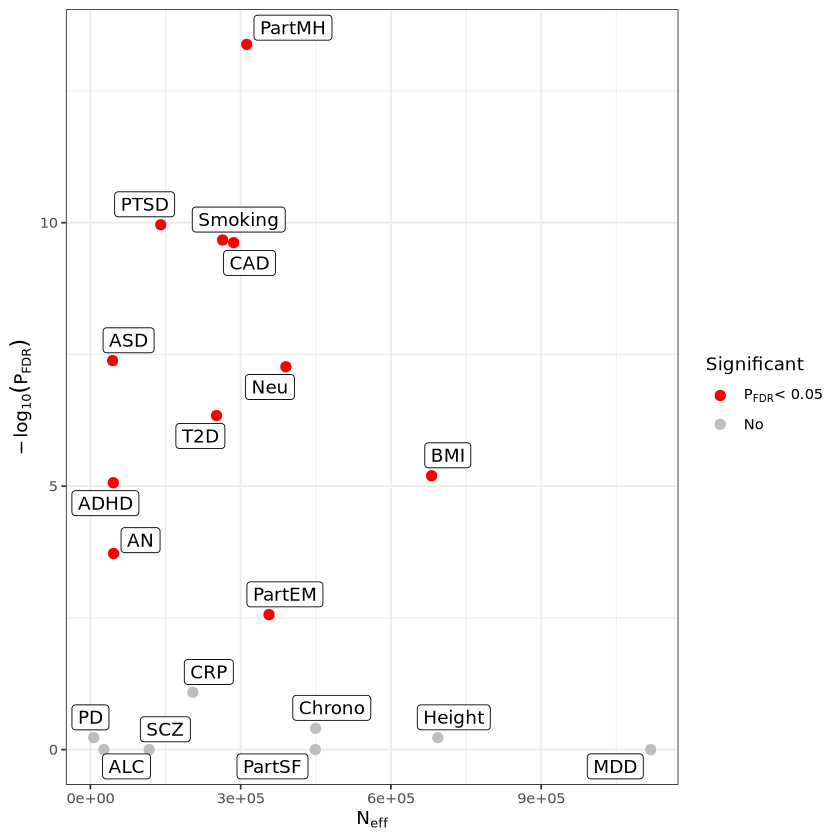

In [126]:
#create a dotplot with -log10(p) on the y axis and neff on the x axis

chisq_diff_plot <- ggplot(model_diff_neff_df, aes(x = Neff, y = -log10(FDR), label = Trait)) +
geom_point(aes(color = Significant), size = 2.5) +
scale_color_manual(values = c("red","grey"), labels = c("FDR < 0.05" = expression(P[FDR]*"< 0.05"))) +
theme_bw() +
geom_label_repel() +
labs(x = expression(N[eff]), y = expression(-log[10](P[FDR]))) 


chisq_diff_plot

In [127]:
ggsave("../plots/bip_paper/mdd_bip/mdd_bip_chisq_diff_bipolar.pdf", chisq_diff_plot, width = 10, height = 10, create.dir = TRUE)

In [128]:
semPlotModel_GSEM <- function(gsem.object=cfa_bipolar){ 
        object <- gsem.object$results
        object$free=0
        numb=1:length(which(object$op!="~~"))
        object$free[which(object$op!="~~")]=numb
        varNames <- lavaanNames(object, type = "ov")
        factNames <- lavaanNames(object, type = "lv")
        factNames <- factNames[!factNames %in% varNames]
        n <- length(varNames)
        k <- length(factNames)
        if (is.null(object$label)) 
          object$label <- rep("", nrow(object))
        semModel <- new("semPlotModel")
        object$std <- object[,"STD_Genotype"]
        object$est <- object[,"Unstand_Est"]
        if (is.null(object$group)) 
          object$group <- ""
        semModel@Pars <- data.frame(label = object$label, lhs = ifelse(object$op == "~" | object$op == "~1", object$rhs, object$lhs), edge = "--", 
                                    rhs = ifelse(object$op == "~" | object$op == "~1", object$lhs, object$rhs), est = object$est, std = object$std, std = NA, group = object$group, 
                                    fixed = object$free==0, par = object$free, stringsAsFactors = FALSE)
        semModel@Pars$edge[object$op == "~~"] <- "<->"
        semModel@Pars$edge[object$op == "~*~"] <- "<->"
        semModel@Pars$edge[object$op == "~"] <- "~>"
        semModel@Pars$edge[object$op == "=~"] <- "->"
        semModel@Pars$edge[object$op == "~1"] <- "int"
        semModel@Pars$edge[grepl("\\|", object$op)] <- "|"
        semModel@Thresholds <- semModel@Pars[grepl("\\|", semModel@Pars$edge), 
                                             -(3:4)]
        semModel@Pars <- semModel@Pars[!object$op %in% c(":=", "<", 
                                                         ">", "==", "|", "<", ">"), ]
        semModel@Vars <- data.frame(name = c(varNames, factNames), 
                                    manifest = c(varNames, factNames) %in% varNames, exogenous = NA, 
                                    stringsAsFactors = FALSE)
        semModel@ObsCovs <- list()
        semModel@ImpCovs <- list()
        semModel@Computed <- FALSE
        semModel@Original <- list(object)
        return(semModel)
 }

In [129]:
library(lavaanPlot)
library(lavaan)
library(semPlot)

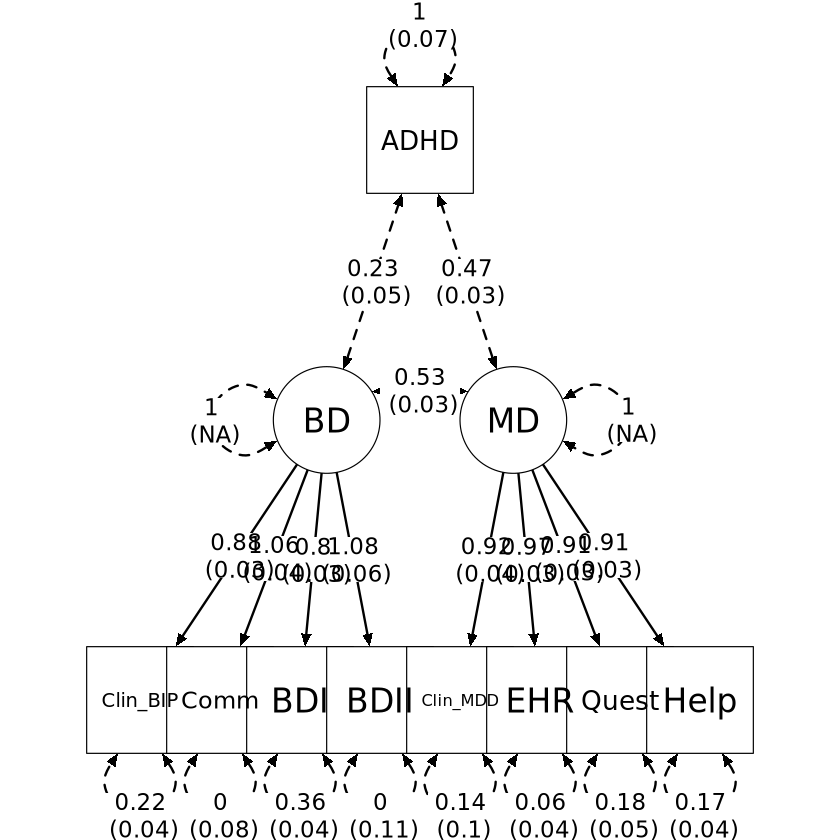

In [130]:
current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[["ADHD"]])

se <- trait_common.fit[["ADHD"]]$results$STD_Genotype_SE
est <- trait_common.fit[["ADHD"]]$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

semPaths(current_fit_common, layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se)

In [131]:
for (trait in other_names){
    #define the two sem objects
    current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[[trait]])
    current_fit_independent <- semPlotModel_GSEM(gsem.object = trait_independent.fit[[trait]])
    #extract the std estimate and the corresponding se to plot them both, for common and independent model
    se <- trait_common.fit[[trait]]$results$STD_Genotype_SE
    est <- trait_common.fit[[trait]]$results$STD_Genotype
    est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

    se_in <- trait_independent.fit[[trait]]$results$STD_Genotype_SE
    est_in <- trait_independent.fit[[trait]]$results$STD_Genotype
    est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")
    #save the common model as an svg object, remove the last label as overlapping and known as factor artificially set to variance of 1
    pdf(paste0("/local1/home/pazweifel/plots/bip_paper/mdd_bip/",trait,"_mdbip_common_model.pdf"), width = 30, height = 25)
    semPaths(current_fit_common, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.6,
        esize = 2,
        edgeLabels = est.se)
    dev.off()
    #save the indpendent mode as an svg object
    pdf(paste0("/local1/home/pazweifel/plots/bip_paper/mdd_bip/",trait,"_mdbip_independent_model.pdf"), width = 30, height = 25)
    semPaths(current_fit_independent, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.6,
        rotation = 1,
        esize = 2,
        edgeLabels = est.se_in)
    dev.off()
}

In [132]:
se <- base.fit$results$STD_Genotype_SE
est <- base.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

se_in <- anchor.fit$results$STD_Genotype_SE
est_in <- anchor.fit$results$STD_Genotype
est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")

In [133]:
fit_sem_base <- semPlotModel_GSEM(base.fit)
fit_sem_anchor <- semPlotModel_GSEM(anchor.fit)

agg_record_562471811 
                   2

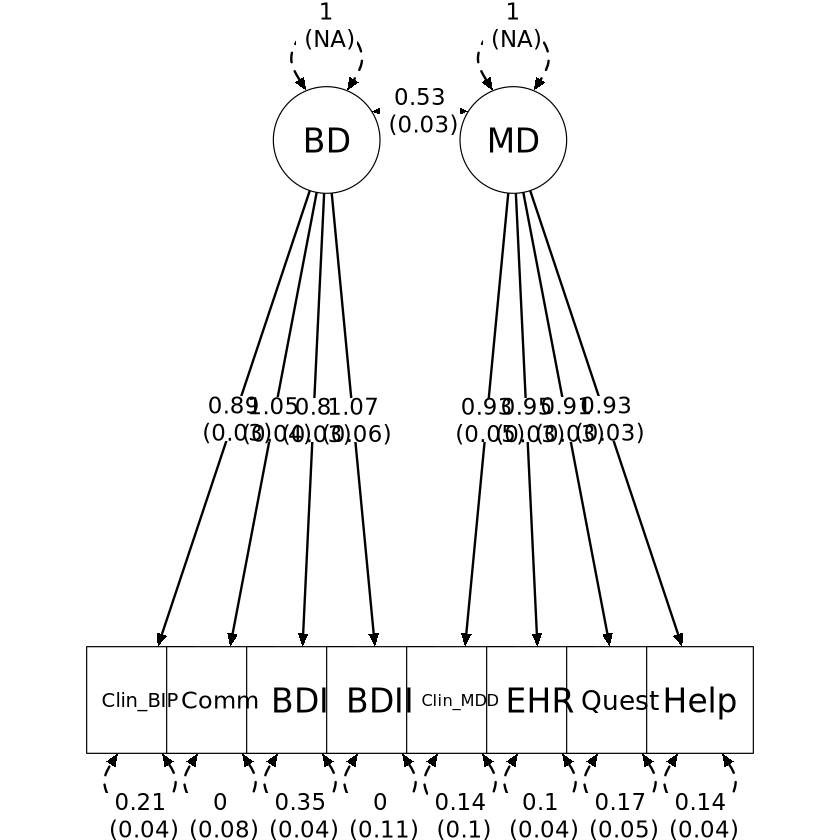

In [134]:
positions <- sapply(c(1:length(est.se)), function(index) {
    if (index%%2==0){
        0.7
    }else {
        0.3}
}
)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/base_model_wse.pdf", width = 30, height = 25)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.6,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )
dev.off()

agg_record_1879859486 
                    2

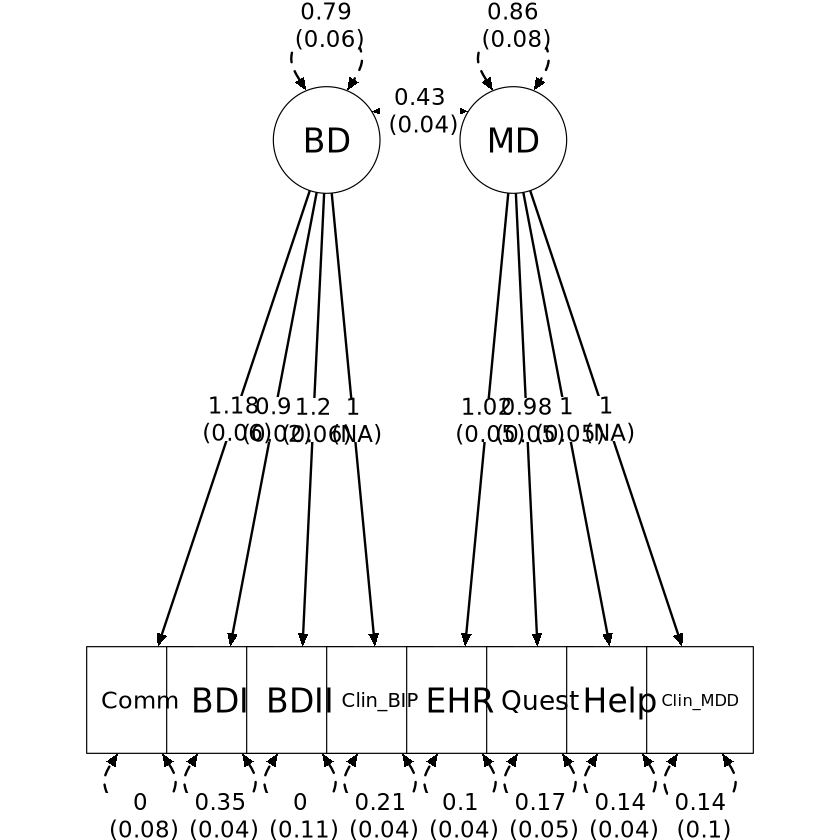

In [135]:
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_in)

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/anchor_model_wse.pdf", width = 30, height = 25)
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.6,
        esize = 2,
        edgeLabels = est.se_in)
dev.off()

## follow up for EA with direct paths to all internal variables

In [136]:
#qtrait with adjusted thresholds
trait.qtrait_adjusted <- bind_rows(lapply(traits, function(trait) {
    QTrait(
    LDSCoutput = trait.covstructs[[trait]],
    indicators = core_names,
    traits = trait,
    mresid = 0.1,
    mresidthreshold = 0.05,
    lsrmr = 0.1,
    lsrmrthreshold = 0.05
    )
    }),
    .id = "Trait")


 ---------------------------- 

 Fitting common pathways model for external trait ADHD 
 

 Fitting independent pathways model for external trait ADHD 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ALC 
 

 Fitting independent pathways model for external trait ALC 
 

 Fitting follow-up model for external trait ALC 
 

 Most egregious outlier: Comm 
 

 ---------------------------- 

 Fitting follow-up model for external trait ALC 
 

 Most egregious outliers: Comm,BDII 
 

 ---------------------------- 

 Fitting follow-up model for external trait ALC 
 

 Most egregious outliers: Comm,BDII,EHR 
 

 ---------------------------- 

 Fitting follow-up model for external trait ALC 
 

 Most egregious outliers: Comm,BDII,EHR,Clin_BIP 
 

 ---------------------------- 

 Fitting follow-up model for external trait ALC 
 

 Most egregious outliers: Comm,BDII,EHR,Clin_BIP,Help 
 

 ---------------------------- 

 Fitting fol

In [137]:
trait.qtrait_adjusted

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ADHD,ADHD,0.44606160,0.03544111,2.521506e-36,*,-44.92406,7,1.000000e+00,NS,0.09419691,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
ALC,ALC,0.54680080,0.07507353,3.251798e-13,*,2450.61284,7,0.000000e+00,*,0.09336023,⋯,1.605523e-04,*,5.821089e-04,0,0.000000e+00,*,0.65679296,Yes,Yes,"Comm,BDII,EHR,Clin_BIP,Help,BDI,Quest"
AN,AN,0.31759418,0.03789934,5.295495e-17,*,133.37442,7,1.238745e-25,*,0.01846216,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
ASD,ASD,0.34411424,0.03904819,1.223284e-18,*,2562.06557,7,0.000000e+00,*,0.03417988,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
MDD,MDD,0.92020936,0.02712592,2.988376e-252,*,1050.71748,7,1.321992e-222,*,0.14508142,⋯,1.545953e-208,*,-7.435718e+02,6,1.000000e+00,NS,0.13181080,Yes,No,EHR
BMI,BMI,0.09418835,0.01751095,7.497277e-08,*,210.99153,7,5.377714e-42,*,0.06642237,⋯,5.905028e-17,*,2.015537e+01,4,4.653352e-04,*,0.04450622,No,No,"BDI,Clin_BIP,Comm"
CAD,CAD,0.18809482,0.02062731,7.601032e-20,*,255.00154,7,2.387025e-51,*,0.08015380,⋯,4.796069e-17,*,1.214177e+02,4,2.659643e-25,*,0.03564922,No,No,"BDI,Clin_BIP,EHR"
Chrono,Chrono,-0.06206881,0.02211459,5.005323e-03,*,-26.53045,7,1.000000e+00,NS,0.02871199,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
CRP,CRP,0.08665090,0.02522553,5.924498e-04,*,2537.90928,7,0.000000e+00,*,0.05216882,⋯,1.348869e-04,*,2.561096e+03,6,0.000000e+00,*,0.04661142,No,No,BDI


In [138]:
max(sapply(trait.qtrait_adjusted$Unconstrained_paths, function(entries) length(str_split_1(entries, pattern = ","))))

[1] 7

In [139]:
#extracting the relevant traits
follow_up_names_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]$Trait
traits[follow_up_names_adjusted]
follow_up_table_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]

ALC       MDD       BMI       CAD       CRP        PD       SCZ   Smoking 
    "ALC"     "MDD"     "BMI"     "CAD"     "CRP"      "PD"     "SCZ" "Smoking" 
      T2D    PartEM    PartMH 
    "T2D"  "PartEM"  "PartMH"

### Follow up models with Bias Factor

In [140]:
follow_up_model_upper_side <- "BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
"

follow_up_bias <- "Bias=~1*{trait}+"

follow_up_model_lower_side <- "
MD ~~ BD
MD ~~ 1*MD
BD~~1*BD
{trait}~~0*{trait}
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001"

follow_up_model_lower_side_non_correlating <- "
MD ~~ BD
{trait} ~~ 0*MD
{trait} ~~ 0*BD
MD ~~ 1*MD
BD~~1*BD
{trait}~~0*{trait}
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001"


In [141]:
their_follow_up_models.fit_adjusted <- lapply(traits[follow_up_names_adjusted], function(trait) {
                                bias_tail <- gsub(",","+",follow_up_table_adjusted[follow_up_table_adjusted$Trait == trait,][1,]$Unconstrained_paths)
                               
                                combined_model <- paste0(follow_up_model_upper_side, follow_up_bias, bias_tail, follow_up_model_lower_side)
                                #fit the follow up model with the pasted construct
                                try({usermodel(covstruc = trait.covstructs[[trait]],
                                          estimation = "DWLS",
                                          model = str_glue(combined_model),
                                          imp_cov = TRUE)
                                    }, silent = TRUE)
         
})


[1] "Running primary model"
[1] "The model as initially specified failed to converge. A lower bound of 0 on residual variances was automatically added to try and troubleshoot this. This behavior can be toggled off by setting the fix_resid argument to FALSE."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The model failed to converge on a solution. Please try specifying an alternative model”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The model failed to converge on a solution. Please try specifying an alternative model.”
Warning message in sqrt(diag(Ohtt)):
“NaNs produced”


[1] "Calculating CFI"
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.404 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027631258039012 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.260305320328371 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.44 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027346166844977 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.256160169393116 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.58 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00271498979973889 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.253564777304245 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.404 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00270921997770598 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259223948618253 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [142]:
"Error" %in% str_split_1(their_follow_up_models.fit_adjusted[["ALC"]][[1]], pattern = " ")

[1] TRUE

In [143]:
"NaN" %in% their_follow_up_models.fit_adjusted[["BIP"]]$results$STD_Genotype_SE

[1] FALSE

In [144]:
#remove the caught error
filtered_follow_up_model_list <- their_follow_up_models.fit_adjusted[2:length(their_follow_up_models.fit_adjusted)]

In [145]:
filtered_follow_up_model_list <- lapply(traits[names(filtered_follow_up_model_list)], function(trait) {
                                        temp <- their_follow_up_models.fit_adjusted[[trait]]
                                        if ("NaN" %in% temp$results$STD_Genotype_SE){
                                            print("NaN" %in% temp$results$STD_Genotype_SE)
                                            NULL}
                                        else{
                                            temp}

    })

[1] TRUE
[1] TRUE


In [146]:
filtered_follow_up_model_list <- Filter(Negate(is.null), filtered_follow_up_model_list)

In [147]:
filter(filtered_follow_up_model_list$MDD$results, lhs == "BD" & rhs == "MD")
names(filtered_follow_up_model_list)

lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
BD,~~,MD,0.5154118,0.0302338089579903,0.5153794,0.030231147008705,0.5153794,3.646103e-65


[1] "MDD"     "BMI"     "CAD"     "CRP"     "Smoking" "T2D"     "PartEM" 
[8] "PartMH"

In [148]:
filter(filtered_follow_up_model_list$MDD$results, lhs == "BD" & rhs == "MD")

factor_correlation_table <- bind_rows(lapply(filtered_follow_up_model_list, function(trait) {
                                        filter(trait$results, lhs == "BD" & rhs == "MD") %>% transmute(
                                            rg = STD_Genotype,
                                            se = as.numeric(STD_Genotype_SE))

    }), 
    .id = "Bias"
)

lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
BD,~~,MD,0.5154118,0.0302338089579903,0.5153794,0.030231147008705,0.5153794,3.646103e-65


In [149]:
factor_correlation_table$base_rg <- filter(base.fit$results, lhs == "BD" & rhs == "MD")$STD_Genotype
factor_correlation_table$base_se <- as.numeric(filter(base.fit$results, lhs == "BD" & rhs == "MD")$STD_Genotype_SE)
factor_correlation_table$observed_rg_clinical <- 0.43
factor_correlation_table$observed_se_clinical <- 0.06

In [150]:
factor_correlation_table <- factor_correlation_table %>% mutate(across(where(is.numeric), round, 2))

In [151]:
factor_correlation_table

Bias,rg,se,base_rg,base_se,observed_rg_clinical,observed_se_clinical
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MDD,0.52,0.03,0.53,0.03,0.43,0.06
BMI,0.54,0.03,0.53,0.03,0.43,0.06
CAD,0.54,0.03,0.53,0.03,0.43,0.06
CRP,0.53,0.03,0.53,0.03,0.43,0.06
Smoking,0.53,0.03,0.53,0.03,0.43,0.06
T2D,0.54,0.03,0.53,0.03,0.43,0.06
PartEM,0.53,0.03,0.53,0.03,0.43,0.06
PartMH,0.52,0.03,0.53,0.03,0.43,0.06


### Follow-up models with factor correlation and direct regression paths

In [152]:
follow_up_model_core_direct <- "BD=~NA*Clin_BIP+Comm+BDI+BDII
MD =~ NA*Clin_MDD + EHR + Quest + Help
MD ~~ BD
BD~~{trait}
MD~~{trait}
BD~~1*BD
MD~~1*MD
Clin_BIP~~a*Clin_BIP
Comm ~~ b*Comm
BDII ~~ c*BDII
a > 0.0001
b > 0.0001
c > 0.0001
"

internal_1_model <- "\n{internal1} ~ d*{trait}"
internal_2_model <- "\n{internal2} ~ e*{trait}"
internal_3_model <- "\n{internal3} ~ f*{trait}"
internal_4_model <- "\n{internal4} ~ g*{trait}"
internal_5_model <- "\n{internal5} ~ h*{trait}"
internal_6_model <- "\n{internal6} ~ i*{trait}"
internal_7_model <- "\n{internal7} ~ j*{trait}"


internal_models <- c(internal_1_model, internal_2_model, internal_3_model, internal_4_model, internal_5_model, internal_6_model, internal_7_model)

In [153]:
#extracting the relevant traits
follow_up_names_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]$Trait
traits[follow_up_names_adjusted]
follow_up_table_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]

ALC       MDD       BMI       CAD       CRP        PD       SCZ   Smoking 
    "ALC"     "MDD"     "BMI"     "CAD"     "CRP"      "PD"     "SCZ" "Smoking" 
      T2D    PartEM    PartMH 
    "T2D"  "PartEM"  "PartMH"

In [154]:
follow_up_table_adjusted

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ALC,ALC,0.54680080,0.07507353,3.251798e-13,*,2450.61284,7,0.000000e+00,*,0.09336023,⋯,1.605523e-04,*,5.821089e-04,0,0.000000e+00,*,0.65679296,Yes,Yes,"Comm,BDII,EHR,Clin_BIP,Help,BDI,Quest"
MDD,MDD,0.92020936,0.02712592,2.988376e-252,*,1050.71748,7,1.321992e-222,*,0.14508142,⋯,1.545953e-208,*,-7.435718e+02,6,1.000000e+00,NS,0.13181080,Yes,No,EHR
BMI,BMI,0.09418835,0.01751095,7.497277e-08,*,210.99153,7,5.377714e-42,*,0.06642237,⋯,5.905028e-17,*,2.015537e+01,4,4.653352e-04,*,0.04450622,No,No,"BDI,Clin_BIP,Comm"
CAD,CAD,0.18809482,0.02062731,7.601032e-20,*,255.00154,7,2.387025e-51,*,0.08015380,⋯,4.796069e-17,*,1.214177e+02,4,2.659643e-25,*,0.03564922,No,No,"BDI,Clin_BIP,EHR"
CRP,CRP,0.08665090,0.02522553,5.924498e-04,*,2537.90928,7,0.000000e+00,*,0.05216882,⋯,1.348869e-04,*,2.561096e+03,6,0.000000e+00,*,0.04661142,No,No,BDI
PD,PD,0.29107481,0.07635021,1.376438e-04,*,2614.99585,7,0.000000e+00,*,0.15238316,⋯,6.331135e-31,*,-4.951292e-01,3,1.000000e+00,NS,0.43629597,Yes,No,"Comm,BDII,BDI,Clin_BIP"
SCZ,SCZ,0.52275657,0.02524246,2.848890e-95,*,1713.37824,7,0.000000e+00,*,0.22477852,⋯,2.890862e-10,*,-4.294789e-03,0,1.000000e+00,NS,0.08045354,Yes,No,"BDI,Clin_BIP,Quest,Comm,Help,EHR,BDII"
Smoking,Smoking,0.23648926,0.02667007,7.499844e-19,*,48.93295,7,2.338626e-08,*,0.06011332,⋯,4.075890e-13,*,6.907281e+01,6,6.334179e-13,*,0.04630790,No,No,EHR
T2D,T2D,0.13243322,0.02029442,6.773063e-11,*,484.18161,7,2.014463e-100,*,0.08113276,⋯,8.172466e-10,*,2.256477e+02,4,1.141475e-47,*,0.04770062,No,No,"BDI,Clin_BIP,EHR"


In [155]:
their_follow_up_models.fit_adjusted_direct <- lapply(traits[follow_up_names_adjusted], function(trait) {
                                outliers <- str_split_1(follow_up_table_adjusted[follow_up_table_adjusted$Trait == trait,][1,]$Unconstrained_paths, pattern = ",")
                                #assign outliers to the variables
                                internal1 <- outliers[1]
                                internal2 <- outliers[2]
                                internal3 <- outliers[3]
                                internal4 <- outliers[4]
                                internal5 <- outliers[5]
                                internal6 <- outliers[6]
                                internal7 <- outliers[7]

                                combined_model <- follow_up_model_core_direct
                                for (i in 1:length(outliers)){
                                    combined_model <- paste0(combined_model, internal_models[i])
                                    
                                }
                                #fit the follow up model with the pasted construct
                                try({usermodel(covstruc = trait.covstructs[[trait]],
                                          estimation = "DWLS",
                                          model = str_glue(combined_model),
                                          imp_cov = TRUE)})
         
})



[1] "Running primary model"
[1] "The model as initially specified failed to converge. A lower bound of 0 on residual variances was automatically added to try and troubleshoot this. This behavior can be toggled off by setting the fix_resid argument to FALSE."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The model failed to converge on a solution. Please try specifying an alternative model”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The model failed to converge on a solution. Please try specifying an alternative model.”


[1] "Calculating CFI"
Error : lavaan->lav_fit_measures():  
   fit measures not available if model did not converge
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  1.206 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027631258039012 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.260305320328371 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.482 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.0027346166844977 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.256160169393116 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.522 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00271498979973889 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.253564777304245 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.457 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00270921997770598 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.259223948618253 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [156]:
#remove the caught error
filtered_follow_up_model_list <- their_follow_up_models.fit_adjusted_direct[2:length(their_follow_up_models.fit_adjusted)]

In [157]:
filtered_follow_up_model_list <- lapply(traits[names(filtered_follow_up_model_list)], function(trait) {
                                        temp <- their_follow_up_models.fit_adjusted_direct[[trait]]
                                        if ("NaN" %in% temp$results$Unstand_SE){
                                            print("NaN" %in% temp$results$Unstand_SE)
                                            NULL}
                                        else{
                                            temp}

    })

[1] TRUE


In [158]:
filtered_follow_up_model_list <- Filter(Negate(is.null), filtered_follow_up_model_list)

In [159]:
filter(filtered_follow_up_model_list$MDD$results, lhs == "BD" & rhs == "MD")

factor_correlation_table <- bind_rows(lapply(filtered_follow_up_model_list, function(trait) {
                                        filter(trait$results, lhs == "BD" & rhs == "MD") %>% transmute(
                                            rg = STD_Genotype,
                                            se = as.numeric(STD_Genotype_SE))

    }), 
    .id = "Bias"
)

lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
BD,~~,MD,0.5154117,0.0302338113313673,0.5153791,0.0302311487699009,0.5153791,3.646419e-65


In [160]:
factor_correlation_table$base_rg <- filter(base.fit$results, lhs == "BD" & rhs == "MD")$STD_Genotype
factor_correlation_table$base_se <- as.numeric(filter(base.fit$results, lhs == "BD" & rhs == "MD")$STD_Genotype_SE)
factor_correlation_table$observed_rg_clinical <- 0.43
factor_correlation_table$observed_se_clinical <- 0.06

In [161]:
factor_correlation_table <- factor_correlation_table %>% mutate(across(where(is.numeric), round, 2))

In [162]:
factor_correlation_table

Bias,rg,se,base_rg,base_se,observed_rg_clinical,observed_se_clinical
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MDD,0.52,0.03,0.53,0.03,0.43,0.06
BMI,0.54,0.03,0.53,0.03,0.43,0.06
CAD,0.54,0.03,0.53,0.03,0.43,0.06
CRP,0.53,0.03,0.53,0.03,0.43,0.06
PD,0.54,0.01,0.53,0.03,0.43,0.06
Smoking,0.53,0.03,0.53,0.03,0.43,0.06
T2D,0.54,0.03,0.53,0.03,0.43,0.06
PartEM,0.53,0.03,0.53,0.03,0.43,0.06
PartMH,0.52,0.03,0.53,0.03,0.43,0.06


### Testing a three factor model; EFA with three factors + CFA with relevant loadings

In [163]:
require(stats)
require(Matrix)
#iterate through all teh covariance structures and do EFA with three factors
trait.3_factor_efa <- lapply(traits, function(trait) {
    #get smoothed covariance matrix
    Ssmooth <- as.matrix((nearPD(trait.covstructs[[trait]]$S, corr = FALSE))$mat)

    #run EFA
    factanal(covmat = Ssmooth, factors = 3, rotation = "promax")
    })

In [164]:
### ADJUSTED VERSION FOR THIS PARTICULAR CASE, DO NOT COPY FOR OTHER ANALYSES! ###
lavaan_structures_from_efa <- function(efa_list, negative_allowed = FALSE, threshold = 0.2){
    #initialize the lavaan structure list
    lavaan_structure_list <- rep(list(0),length(efa_list))

    #iterate through the efa list to build the lavaan structures for each model
    for (i in 1:length(efa_list)){
        factor_lavaan_list <- rep(list(0),i)
    
        #extract the relevant trait on factor loadings and define the lavaan structure
        
        for (factor_index in 1:3){
            #for each factor loading column of an i-factor model, extract the names of the relevant traits (loading > 0.2)
            #and paste them together usign lavaan syntax
            loadings <- efa_list[[i]]$loadings[,factor_index]
            
            if (negative_allowed){
                relevant_loadings_traits <- names(loadings[abs(loadings) > threshold])
            }
            else{
                relevant_loadings_traits <- names(loadings[loadings > threshold])
            }
            
            factor_lavaan_list[[factor_index]] <- paste0("F",as.character(factor_index),
                                                 " =~NA*", 
                                                 paste(relevant_loadings_traits, collapse = "+")
                                                 )
            }
    
        #define the correlations between the individual factors if i > 1
             
        if (TRUE){
            factor_numbers <- seq(1,3)
            #get all the pairwise unique combinations of factors
            combination_matrix <- t(combn(factor_numbers, 2))
            print(nrow(combination_matrix))
            factor_correlation_list <- rep(list(0), nrow(combination_matrix))
            for (combination in 1:nrow(combination_matrix)){
                f_left <- as.character(combination_matrix[combination, 1])
                f_right <- as.character(combination_matrix[combination, 2])
        
                factor_correlation_list[[combination]] <- paste0("F",f_left,"~~","F",f_right)
            }
            #collapse the lists and create one lavaan structure object
            collapsed_factor_loadings <- paste(factor_lavaan_list, collapse = "\n")
            collapsed_factor_correlations <- paste(factor_correlation_list, collapse = "\n")
        
            lavaan_structure_list[[i]] <- paste(collapsed_factor_loadings, collapsed_factor_correlations, sep = "\n")
        }
        else{
            lavaan_structure_list[[i]] <- paste(factor_lavaan_list, collapse = "\n")
        }
    }
    lavaan_structure_list
}

In [165]:
lavaan_structures.3_factor_efa <- lapply(traits, function(trait){
    lavaan_structures_from_efa(trait.3_factor_efa[trait], negative_allowed = TRUE, threshold = 0.15)
    })

[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3
[1] 3


In [166]:
lavaan_structures.3_factor_efa

$ADHD
$ADHD[[1]]
[1] "F1 =~NA*Clin_BIP+Comm+BDI+BDII\nF2 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDII+ADHD\nF3 =~NA*Clin_MDD+BDII+ADHD\nF1~~F2\nF1~~F3\nF2~~F3"


$ALC
$ALC[[1]]
[1] "F1 =~NA*Clin_BIP+Comm+BDI+BDII\nF2 =~NA*Clin_MDD+EHR+Quest+Help+ALC\nF3 =~NA*Clin_MDD+BDI+BDII\nF1~~F2\nF1~~F3\nF2~~F3"


$AN
$AN[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*AN\nF1~~F2\nF1~~F3\nF2~~F3"


$ASD
$ASD[[1]]
[1] "F1 =~NA*Clin_BIP+Comm+BDI+BDII\nF2 =~NA*Clin_MDD+EHR+Quest+Help\nF3 =~NA*Clin_MDD+EHR+Comm+BDI+BDII+ASD\nF1~~F2\nF1~~F3\nF2~~F3"


$MDD
$MDD[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+BDII+MDD\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*Clin_MDD+Help+BDI+BDII\nF1~~F2\nF1~~F3\nF2~~F3"


$BMI
$BMI[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*BMI\nF1~~F2\nF1~~F3\nF2~~F3"


$CAD
$CAD[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*CAD\nF1~~F2\nF1~~F3\nF2~~F3"


$Chrono
$Chrono[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*Chrono\nF1~~F2\nF1~~F3\nF2~~F3"


$CRP
$CRP[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*CRP\nF1~~F2\nF1~~F3\nF2~~F3"


$Height
$Height[[1]]
[1] "F1 =~NA*Clin_BIP+Comm+BDI+BDII\nF2 =~NA*Clin_MDD+EHR+Quest+Help\nF3 =~NA*Clin_MDD+EHR+Comm+BDI+BDII\nF1~~F2\nF1~~F3\nF2~~F3"


$Neu
$Neu[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII+Neu\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*Neu\nF1~~F2\nF1~~F3\nF2~~F3"


$PD
$PD[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*PD\nF1~~F2\nF1~~F3\nF2~~F3"


$PTSD
$PTSD[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*EHR+Help+Comm+PTSD\nF1~~F2\nF1~~F3\nF2~~F3"


$SCZ
$SCZ[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*SCZ\nF1~~F2\nF1~~F3\nF2~~F3"


$Smoking
$Smoking[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*Smoking\nF1~~F2\nF1~~F3\nF2~~F3"


$T2D
$T2D[[1]]
[1] "F1 =~NA*Clin_BIP+Comm+BDI+BDII\nF2 =~NA*Clin_MDD+EHR+Quest+Help+T2D\nF3 =~NA*Clin_MDD+EHR+BDI+BDII\nF1~~F2\nF1~~F3\nF2~~F3"


$PartEM
$PartEM[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*PartEM\nF1~~F2\nF1~~F3\nF2~~F3"


$PartMH
$PartMH[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*PartMH\nF1~~F2\nF1~~F3\nF2~~F3"


$PartSF
$PartSF[[1]]
[1] "F1 =~NA*Clin_MDD+EHR+Quest+Help+Comm+BDI+BDII\nF2 =~NA*Clin_BIP+Comm+BDI+BDII\nF3 =~NA*PartSF\nF1~~F2\nF1~~F3\nF2~~F3"

In [167]:
fit.3_factor_efa <- lapply(traits, function(trait) {
    usermodel(
        trait.covstructs[[trait]],
        estimation = "DWLS",
        model = lavaan_structures.3_factor_efa[[trait]][[1]],
        imp_cov = TRUE
        )})


[1] "Running primary model"


Warning message in sqrt(diag(Ohtt)):
“NaNs produced”


[1] "Calculating CFI"
[1] "Calculating Standardized Results"


Warning message in sqrt(diag(Ohtt_stand)):
“NaNs produced”


[1] "Calculating SRMR"


...

Warning message in sqrt(diag(Ohtt_stand)):
“NaNs produced”


[1] "Calculating SRMR"


Warning message:
“lavaan->lav_model_vcov():  
   Could not compute standard errors! The information matrix could not be 
   inverted. This may be a symptom that the model is not identified.”


elapsed 
   0.41 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00275780853289925 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.46925602258717 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = lavaan_structures.3_factor_efa[[trait]][[1]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = lavaan_structures.3_factor_efa[[trait]][[1]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = lavaan_structures.3_factor_efa[[trait]][[1]], :
“

In [168]:
colnames(covstruct_core$S_Stand)

[1] "Clin_MDD" "EHR"      "Quest"    "Help"     "Clin_BIP" "Comm"     "BDI"     
[8] "BDII"

### Reference "Liability" Model without bias factors including BDI/BDII

In [169]:
reference_model_2_factors <- "
Liability_BD =~ 1*Clin_BIP + Comm + BDI + BDII
Liability_MD =~ 1*Clin_MDD + EHR + Quest + Help
Comm ~~ b*Comm
b > 0.0001
BDII ~~ a*BDII
a > 0.0001
"

In [170]:
reference_2_factor.fit <- usermodel(covstruc = covstruct_core, estimation = "DWLS", model = reference_model_2_factors, CFIcalc = TRUE, imp_cov = TRUE)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.368 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00273284163554166 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.256201817609998 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = covstruct_core, estimation = "DWLS", model = reference_model_2_factors, :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [171]:
reference_2_factor.fit

$modelfit
      chisq df       p_chisq      AIC       CFI       SRMR
df 626.4536 19 1.310442e-120 660.4536 0.9364171 0.09950233

$results
            lhs op          rhs Unstand_Est          Unstand_SE STD_Genotype
11 Liability_BD =~         Comm 0.645706909  0.0337938674207858   1.18421553
8  Liability_BD =~          BDI 0.748523538  0.0191605932293323   0.90429223
9  Liability_BD =~         BDII 0.796554723  0.0392779342437499   1.20117845
15 Liability_MD =~          EHR 0.758898695  0.0389660646321131   1.02461057
17 Liability_MD =~        Quest 0.879670985  0.0477389853973388   0.98322613
16 Liability_MD =~         Help 0.972294686  0.0500026487317253   0.99757342
5          Comm ~~         Comm 0.000100000 0.00435875737476666   0.00010000
2          BDII ~~         BDII 0.000100000 0.00916508436524759   0.00010000
4      Clin_MDD ~~     Clin_MDD 0.013562178  0.0100688714583801   0.13817477
6           EHR ~~          EHR 0.005126997 0.00230212978133306   0.09522974
19        Quest ~~        Quest 0.013108782 0.00391832490257094   0.16684112
7          Help ~~         Help 0.013273577 0.00405864434452447   0.14234901
3      Clin_BIP ~~     Clin_BIP 0.039465331 0.00731783374354081   0.20762610
1           BDI ~~          BDI 0.045869439  0.0049668005287165   0.35203927
12 Liability_BD ~~ Liability_BD 0.150729903  0.0108094090738937   0.79237501
18 Liability_MD ~~ Liability_MD 0.084591034 0.00822104118962697   0.86182855
13 Liability_BD ~~ Liability_MD 0.059423878 0.00564499078069019   0.43486522
10 Liability_BD =~     Clin_BIP 1.000000000                       1.00000000
14 Liability_MD =~     Clin_MDD 1.000000000                       1.00000000
      STD_Genotype_SE   STD_All              p_value
11 0.0619740411007762 1.1842155 2.19868259742989e-81
8  0.0231465914241391 0.8049600             < 5e-300
9    0.05922184336345 1.2011785 1.93309693558997e-91
15 0.0526086458943169 0.9511941 1.75850016101933e-84
17 0.0533581589659819 0.9127753 8.02605456650418e-76
16  0.051302302911056 0.9260945 3.22130037400452e-84
5  0.0770474342643467 0.0001000    0.981696283979302
2   0.109544528907471 0.0001000    0.991294474791345
4    0.10258374459607 0.1381743    0.177999177320035
6  0.0427530942342771 0.0952297   0.0259427938536523
19 0.0498720047442583 0.1668412 0.000821323557878299
7  0.0435279231251897 0.1423490  0.00107378077033905
3  0.0384746779188638 0.2076259 6.92775918359836e-08
1  0.0381123558752436 0.3520394 2.57783393830473e-20
12 0.0568289766626228 0.7923750 3.40660330182709e-44
18 0.0837570753640386 0.8618286 7.85207971283878e-25
13 0.0413122607887404 0.5262339 6.49837584360638e-26
10                    0.8901540                 <NA>
14                    0.9283457                 <NA>

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
           Clin_MDD        EHR      Quest       Help   Clin_BIP       Comm
Clin_MDD 0.09815321 0.06419603 0.07441228 0.08224741 0.05942388 0.03837041
EHR      0.06419603 0.05384528 0.05647138 0.06241745 0.04509670 0.02911925
Quest    0.07441228 0.05647138 0.07856710 0.07235066 0.05227346 0.03375334
Help     0.08224741 0.06241745 0.07235066 0.09324230 0.05777752 0.03730734
Clin_BIP 0.05942388 0.04509670 0.05227346 0.05777752 0.19019523 0.09732734
Comm     0.03837041 0.02911925 0.03375334 0.03730734 0.09732734 0.06294494
BDI      0.04448017 0.03375594 0.03912792 0.04324783 0.11282488 0.07285180
BDII     0.04733437 0.03592199 0.04163867 0.04602296 0.12006462 0.07752655
                BDI       BDII
Clin_MDD 0.04448017 0.04733437
EHR      0.03375594 0.03592199
Quest    0.03912792 0.04163867
Help     0.04324783 0.04602296
Clin_BIP 0.11282488 0.12006462
Comm     0.07285180 0.07752655
BDI      0.13032152 0.08987119
BDII     0.08987119 0.09573804

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin_MDD           EHR         Quest          Help      Clin_BIP
Clin_MDD  3.206458e-08 -3.375923e-03 -4.031251e-03 -1.001867e-03 -3.387616e-04
EHR 

In [172]:
two_factor_ref_semobject <- semPlotModel_GSEM(reference_2_factor.fit)

In [173]:
se <- reference_2_factor.fit$results$STD_Genotype_SE
est <- reference_2_factor.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/2_factor_base_model_wse.pdf", width = 30, height = 35)
semPaths(two_factor_ref_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)
dev.off()

agg_record_965709128 
                   2

### Non-correlating bias model

In [174]:
base_model_4_factors <- "
Liability_BD =~ 1*Clin_BIP + Comm + BDI + BDII
Bias_BD =~ NA*Comm + BDI + BDII

Liability_MD =~ 1*Clin_MDD + EHR + Quest + Help
Bias_MD =~ NA*EHR + Quest + Help

Liability_BD ~~ 0*Bias_BD
Liability_BD ~~ 0*Bias_MD
Liability_MD ~~ 0*Bias_MD
Liability_MD ~~ 0*Bias_BD
"

In [175]:
four_factor.fit <- usermodel(covstruc = covstruct_core, estimation = "DWLS", model = base_model_4_factors, CFIcalc = TRUE, imp_cov = TRUE)

[1] "Running primary model"


Warning message in sqrt(diag(Ohtt)):
“NaNs produced”


[1] "Error: The primary model produced correlations among your latent variables that are either greater than 1 or less than -1, or the latent variables have negative variances. \n              Consequently, model fit estimates could not be computed and results should likely not be interpreted. Results are provided below \n              to enable troubleshooting. A model constraint that constrains the latent correlations to be above -1, less than 1, or to have positive variances is suggested."
            lhs op          rhs Unstandardized_Estimate          SE
2  Liability_BD =~         Comm             0.549006796 0.021835488
3  Liability_BD =~          BDI             0.776133576 0.017927081
4  Liability_BD =~         BDII             0.649741672 0.083358276
5       Bias_BD =~         Comm             0.947041286         NaN
6       Bias_BD =~          BDI            -0.208305568 0.246742673
7       Bias_BD =~         BDII             1.499312390 0.762219225
9  Liability_MD =~        

In [176]:
four_factor.fit

NULL

In [177]:
four_factor_model_semobject <- semPlotModel_GSEM(four_factor.fit)

ERROR: Error in rep("", nrow(object)): invalid 'times' argument


In [ ]:
se <- four_factor.fit$results$STD_Genotype_SE
est <- four_factor.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/4_factor_base_model_wse.pdf", width = 30, height = 35)
semPaths(four_factor_model_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)
dev.off()

In [ ]:
semPaths(four_factor_model_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)

### Four factor fit (-BD subtypes)

In [ ]:
base_model_4_factors_nosubtypes <- "
Liability_BD =~ 1*Clin_BIP + Comm 
Bias_BD =~ NA*Comm 

Liability_MD =~ 1*Clin_MDD + EHR + Quest + Help
Bias_MD =~ NA*EHR + Quest + Help

Liability_BD ~~ 0*Bias_BD
Liability_BD ~~ 0*Bias_MD
Liability_MD ~~ 0*Bias_MD
Liability_MD ~~ 0*Bias_BD
"

In [ ]:
four_factor_no_subtypes.fit <- usermodel(covstruc = covstruct_core, estimation = "DWLS", model = base_model_4_factors_nosubtypes, CFIcalc = TRUE, std.lv = TRUE, imp_cov = TRUE)

In [ ]:
four_factor_no_subtypes.fit

In [ ]:
four_factor_nosubtypes_model_semobject <- semPlotModel_GSEM(four_factor_no_subtypes.fit)

In [ ]:
se <- four_factor_no_subtypes.fit$results$STD_Genotype_SE
est <- four_factor_no_subtypes.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/4_factor_nosubtypes_base_model_wse.pdf", width = 30, height = 35)
semPaths(four_factor_nosubtypes_model_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)
dev.off()

In [ ]:
semPaths(four_factor_nosubtypes_model_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)

### 3 factor fit (1 bias factor)

In [ ]:
base_model_3_factors <- "
Liability_BD =~ 1*Clin_BIP + Comm
Liability_MD =~ 1*Clin_MDD + EHR + Quest + Help

Bias =~ NA*EHR + Quest + Help + Comm

Liability_BD ~~ 0*Bias
Liability_MD ~~ 0*Bias
Comm ~~ a*Comm
a > 0.001
"

In [ ]:
three_factors.fit <- usermodel(covstruc = covstruct_core, estimation = "DWLS", model = base_model_3_factors, CFIcalc = TRUE, std.lv = TRUE, imp_cov = TRUE)

In [ ]:
three_factors.fit

In [ ]:
three_factors_semobject <- semPlotModel_GSEM(three_factors.fit)

In [ ]:
se <- three_factors.fit$results$STD_Genotype_SE
est <- three_factors.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

pdf("/local1/home/pazweifel/plots/bip_paper/mdd_bip/3_factor_model.pdf", width = 30, height = 35)
semPaths(three_factors_semobject, layout = "spring", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)
dev.off()

In [ ]:
semPaths(three_factors_semobject, layout = "spring", repulsion = 10, edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)

### Model with BIP factor and non-orthogonal bias factors loading onto outlier traits

In [ ]:
#estimate the complete cov matrix so that you can use it for whatever
follow_up_traits <- c("ADHD", "Neu", "MDD")
#create a matrices directory
dir.create("matrices_mdd_bip", showWarnings = FALSE)
#create a path for a covstruct object where you store the covariance structure of the bipolar disorders and store it in the matrices directory
covstruct_all_path <- here::here("matrices_mdd_bip",paste("follow_up_bip_plus_clin_md", "R", sep = "."))
#extract population prevalence 
pop_prev <- c(all_prevalences[core_names],all_prevalences[follow_up_traits])
#fill the samp_prev vector depending on the pop_prev vector, if NA use NA and if not use 0.5
samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))

samples_all <- samples

for (trait in follow_up_traits){
    if (phenotype == "MDD"){
            samples_all <- c(samples_all, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
    }
    else {
            samples_all <- c(samples_all, paste0(other_basepath,phenotype,".sumstats.gz"))
    }
}
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
if (!file.exists(covstruct_all_path)){
    covstruct_all <- ldsc(
        traits = samples_all,
        trait.names = c(core_names, follow_up_traits),
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_all, covstruct_all_path, control = c("all", "digits17"))
}

In [ ]:
complete_covstruct <- dget("matrices_mdd_bip/follow_up_bip_plus_clin_md.R")

In [ ]:
bip_clean_factor_model <- "
Liability =~ NA*Clin_BIP + Comm + BDI + BDII
Bias_MDD =~ NA*MDD + BDII
Bias_Neu =~ NA*Neu + BDII
Bias_ADHD =~ NA*ADHD + BDII
Liability_MD =~ NA*MDD 

Clin_BIP ~~ 0*Clin_BIP
MDD ~~ Neu + ADHD + MDD
MDD ~~ 0*MDD
Neu ~~ 0*Neu
ADHD ~~ 0*ADHD
Bias_Neu ~~ 0*Bias_MDD
Bias_Neu ~~ 0*Bias_ADHD
Bias_ADHD ~~ 0*Bias_MDD
"


In [ ]:
usermodel(complete_covstruct, model = bip_clean_factor_model, estimation = "DWLS", std.lv = TRUE)

### Create tables for paper

### Lists with modelfits